In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# โหลดข้อมูล (สมมติว่าคุณอัปโหลดไฟล์ train.csv ลงใน Colab แล้ว)
df = pd.read_csv('train.csv')

# ลบคอลัมน์ที่ไม่ได้ใช้ (ID และ Index)
df = df.drop(['Unnamed: 0', 'id'], axis=1)

# ตรวจสอบข้อมูลเบื้องต้น
print(f"Dataset Shape: {df.shape}")
df.info()

Dataset Shape: (103904, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Gender                             103904 non-null  object 
 1   Customer Type                      103904 non-null  object 
 2   Age                                103904 non-null  int64  
 3   Type of Travel                     103904 non-null  object 
 4   Class                              103904 non-null  object 
 5   Flight Distance                    103904 non-null  int64  
 6   Inflight wifi service              103904 non-null  int64  
 7   Departure/Arrival time convenient  103904 non-null  int64  
 8   Ease of Online booking             103904 non-null  int64  
 9   Gate location                      103904 non-null  int64  
 10  Food and drink                     103904 non-null  int64  
 11  Online boar

ทำ EDA และจัดการ Missing Values

/tmp/ipykernel_5022/2194131751.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='satisfaction', data=df, palette='viridis')


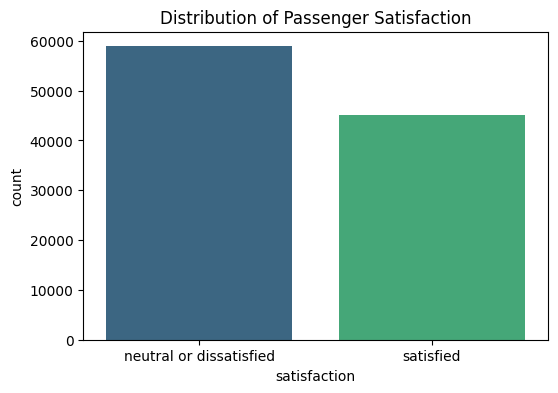

Missing values in each column:
 Arrival Delay in Minutes    310
dtype: int64


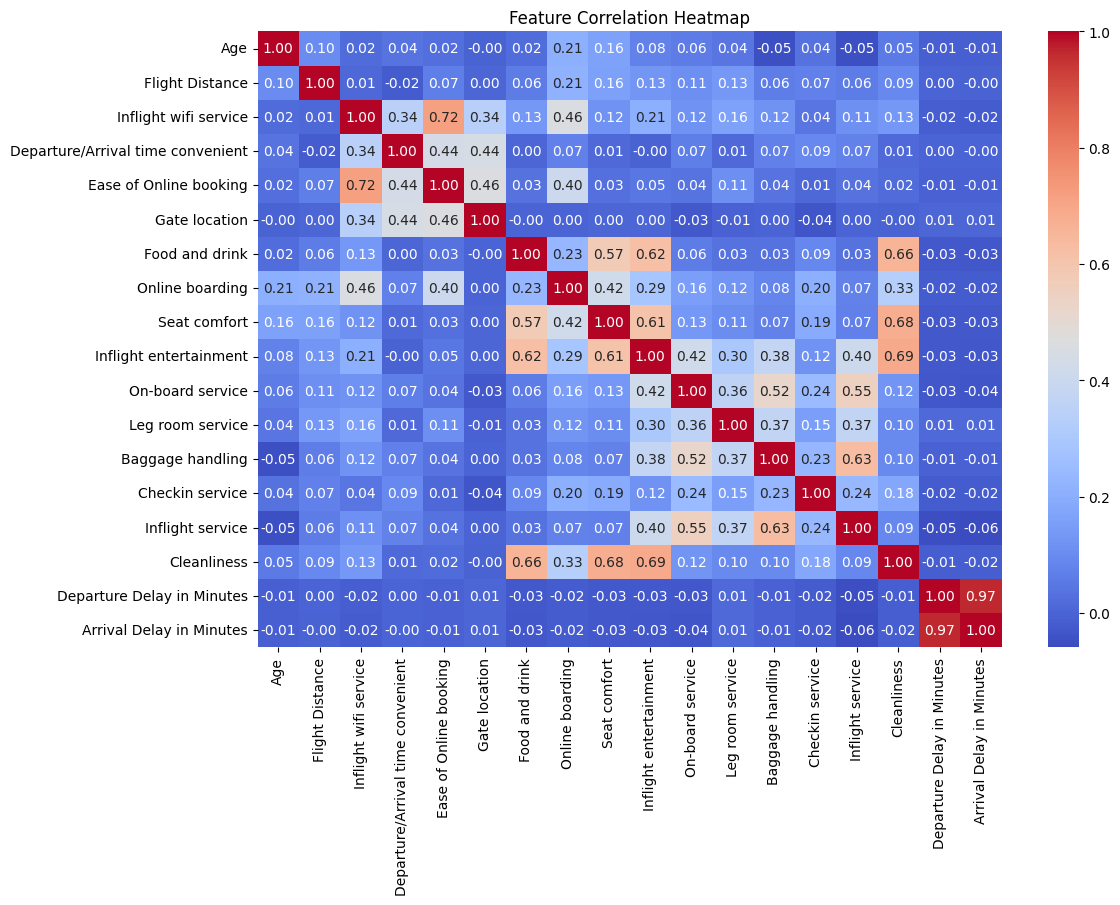

In [2]:
# 1. วิเคราะห์ Distribution ของเป้าหมาย (Satisfaction)
plt.figure(figsize=(6, 4))
sns.countplot(x='satisfaction', data=df, palette='viridis')
plt.title('Distribution of Passenger Satisfaction')
plt.show()

# 2. ตรวจสอบ Missing Values
# พบว่า 'Arrival Delay in Minutes' มักจะมีค่าว่าง
missing_val = df.isnull().sum()
print("Missing values in each column:\n", missing_val[missing_val > 0])

# จัดการ Missing Values: เราจะใช้ Median เพราะข้อมูล Delay มักจะมี Outliers (มีเหตุผลประกอบ )
# (ขั้นตอนนี้เราจะไปใส่ใน Pipeline เพื่อความถูกต้องตามเกณฑ์ )

# 3. ดูความสัมพันธ์ของ Features (Correlation)
plt.figure(figsize=(12, 8))
# เลือกเฉพาะคอลัมน์ที่เป็นตัวเลข
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

สร้าง Pipeline และ Preprocessing

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# แยก Features และ Target
X = df.drop('satisfaction', axis=1)
y = df['satisfaction'].map({'neutral or dissatisfied': 0, 'satisfied': 1})

# แบ่งกลุ่มข้อมูล
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# กำหนดคอลัมน์ตามประเภท
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

# สร้าง Transformer สำหรับข้อมูลตัวเลข (จัดการค่าว่าง + ปรับสเกล)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # จัดการ missing values
    ('scaler', StandardScaler()) # ปรับสเกลข้อมูล
])

# สร้าง Transformer สำหรับข้อมูลหมวดหมู่ (ทำ One-Hot Encoding)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# รวมการจัดการข้อมูลเข้าด้วยกัน
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print("Preprocessing Pipeline Created Successfully!")

Preprocessing Pipeline Created Successfully!


พัฒนาโมเดลและการเปรียบเทียบ

In [4]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

# สร้าง Pipeline สำหรับแต่ละโมเดล
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                             ('classifier', RandomForestClassifier(random_state=42))])

xgb_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', XGBClassifier(random_state=42))])

# ทำ Cross-validation (K-fold) เพื่อเปรียบเทียบ [cite: 29]
rf_cv_scores = cross_val_score(rf_pipeline, X_train, y_train, cv=5)
xgb_cv_scores = cross_val_score(xgb_pipeline, X_train, y_train, cv=5)

print(f"Random Forest CV Accuracy: {rf_cv_scores.mean():.4f}")
print(f"XGBoost CV Accuracy: {xgb_cv_scores.mean():.4f}")

Random Forest CV Accuracy: 0.9624
XGBoost CV Accuracy: 0.9623


การจูน Hyperparameter และการวัดผลละเอียด

In [5]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix

# ตั้งค่า Parameter ที่จะจูน (ตัวอย่างสำหรับ Random Forest)
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [10, 20, None],
}

# ใช้ GridSearchCV [cite: 27]
grid_search = GridSearchCV(rf_pipeline, param_grid, cv=3, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")

# ทำนายผลและรายงานผลด้วย Metrics ที่เหมาะสม [cite: 28]
y_pred = grid_search.predict(X_test)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Best Parameters: {'classifier__max_depth': None, 'classifier__n_estimators': 200}

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.98      0.97     11713
           1       0.98      0.94      0.96      9068

    accuracy                           0.96     20781
   macro avg       0.96      0.96      0.96     20781
weighted avg       0.96      0.96      0.96     20781



บันทึกโมเดลเพื่อนำไป Deploy

In [6]:
import joblib

# บันทึกโมเดลที่ดีที่สุด (Pipeline ทั้งชุด)
joblib.dump(grid_search.best_estimator_, 'airline_satisfaction_model.pkl')
print("Model saved as .pkl file!")

Model saved as .pkl file!


--- ข้อมูลเบื้องต้น ---
ขนาดข้อมูล: (103904, 23)
   Gender      Customer Type  Age   Type of Travel     Class  Flight Distance  \
0    Male     Loyal Customer   13  Personal Travel  Eco Plus              460   
1    Male  disloyal Customer   25  Business travel  Business              235   
2  Female     Loyal Customer   26  Business travel  Business             1142   
3  Female     Loyal Customer   25  Business travel  Business              562   
4    Male     Loyal Customer   61  Business travel  Business              214   

   Inflight wifi service  Departure/Arrival time convenient  \
0                      3                                  4   
1                      3                                  2   
2                      2                                  2   
3                      2                                  5   
4                      3                                  3   

   Ease of Online booking  Gate location  ...  Inflight entertainment  \
0           

/tmp/ipykernel_5022/2840533056.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='satisfaction', data=df, palette='viridis')


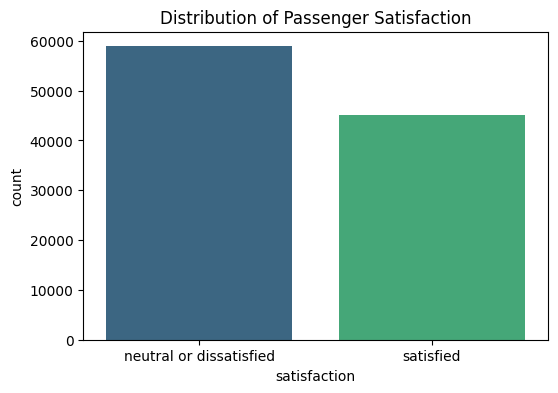


--- ค่าที่หายไปในแต่ละคอลัมน์ ---
Arrival Delay in Minutes    310
dtype: int64


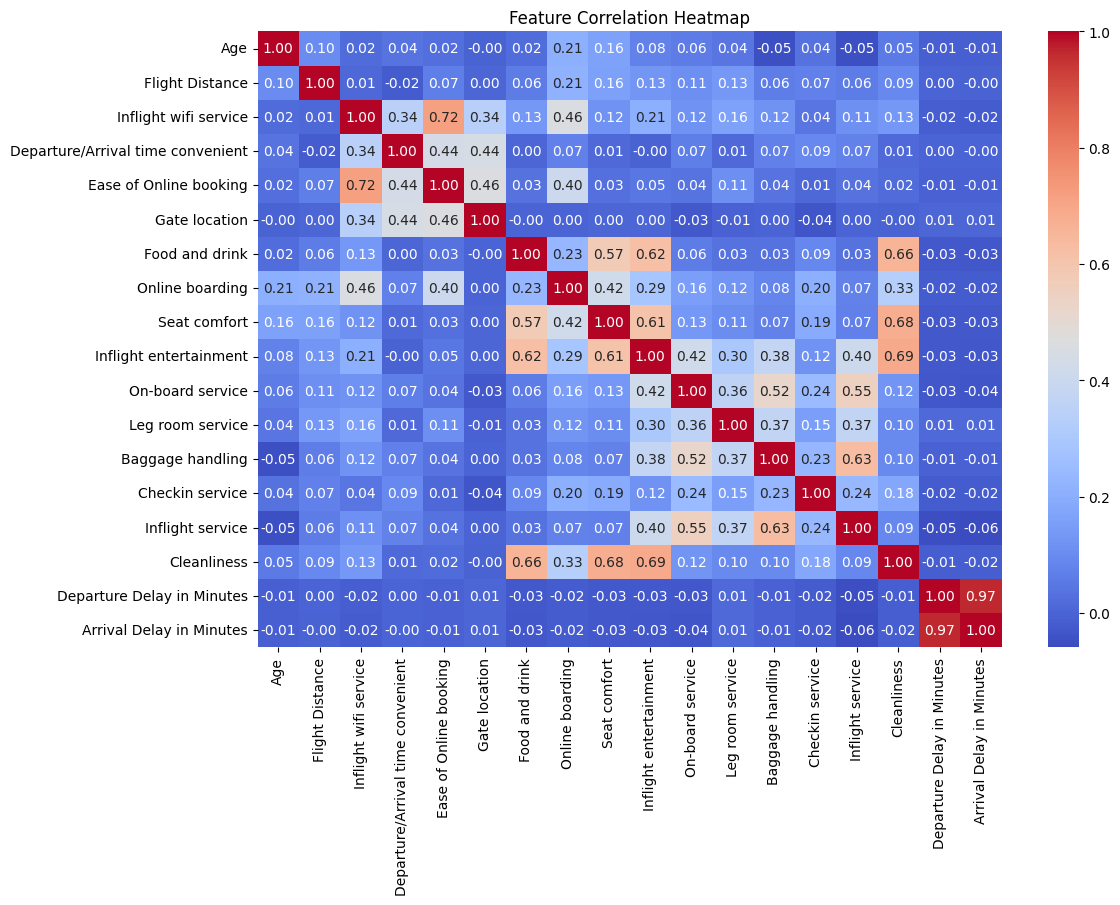


--- กำลังทำ Cross-validation เพื่อเปรียบเทียบโมเดล ---
Random Forest CV Accuracy: 0.9624
XGBoost CV Accuracy: 0.9623

Best Parameters จากการจูน: {'classifier__max_depth': None, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     11713
           1       0.97      0.94      0.96      9068

    accuracy                           0.96     20781
   macro avg       0.96      0.96      0.96     20781
weighted avg       0.96      0.96      0.96     20781



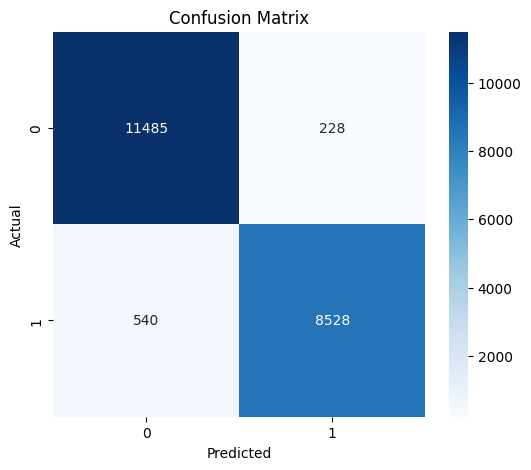


✅ บันทึกโมเดลสำเร็จเป็นไฟล์ 'airline_satisfaction_pipeline.pkl'


In [7]:
# ==========================================
# ✈️ Project: Airline Passenger Satisfaction
# Goal: Get Full Marks (25/25 + Bonus)
# Step: EDA & Model Development (Pipeline)
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# 1. การโหลดข้อมูลและทำความสะอาดเบื้องต้น (หมวดที่ 1)
df = pd.read_csv('train.csv')

# ลบคอลัมน์ที่ไม่ได้ใช้ (ID และ Index) เพื่อความสะอาดของข้อมูล
df = df.drop(['Unnamed: 0', 'id'], axis=1)

print("--- ข้อมูลเบื้องต้น ---")
print(f"ขนาดข้อมูล: {df.shape}")
print(df.head())

# ==========================================
# 📊 หมวดที่ 2: EDA (คะแนนเต็ม 5)
# เราต้องแสดงให้เห็นว่าเราเข้าใจ Distribution ของข้อมูล
# ==========================================

# 1. วิเคราะห์เป้าหมาย (Class Balance)
plt.figure(figsize=(6, 4))
sns.countplot(x='satisfaction', data=df, palette='viridis')
plt.title('Distribution of Passenger Satisfaction')
plt.show()

# 2. ตรวจสอบ Missing Values (เกณฑ์: จัดการอย่างมีเหตุผล)
missing = df.isnull().sum()
print("\n--- ค่าที่หายไปในแต่ละคอลัมน์ ---")
print(missing[missing > 0])
# พบว่า Arrival Delay มักจะมีค่าว่าง เราจะใช้ Median ใน Pipeline ภายหลัง

# 3. วิเคราะห์ความสัมพันธ์ของปัจจัยต่างๆ (Heatmap)
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

# ==========================================
# ⚙️ หมวดที่ 2 & 3: การสร้าง Pipeline และ Preprocessing (คะแนนเต็ม 5)
# เกณฑ์ระบุว่า: ต้องใช้ Pipeline รวม Preprocessing เข้ากับโมเดล
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# แยก Features และ Target
X = df.drop('satisfaction', axis=1)
y = df['satisfaction'].map({'neutral or dissatisfied': 0, 'satisfied': 1})

# แบ่งข้อมูล Training และ Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ระบุประเภทของ Features
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

# สร้าง Pipeline สำหรับข้อมูลตัวเลข (เติมค่าว่างด้วย Median + ปรับสเกล)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# สร้าง Pipeline สำหรับข้อมูลข้อความ (ทำ One-Hot Encoding)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# รวมการจัดการข้อมูลเข้าด้วยกัน
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# ==========================================
# 🏆 หมวดที่ 3 & โบนัส: Model Development และการจูน (คะแนนเต็ม 5 + โบนัส 2)
# เราจะเปรียบเทียบ RF กับ XGBoost และใช้ GridSearchCV
# ==========================================

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix

# 1. เปรียบเทียบโมเดลเบื้องต้น (เพื่อคะแนนโบนัสเปรียบเทียบระบบ)
rf_test_pipe = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', RandomForestClassifier(random_state=42))])

xgb_test_pipe = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', XGBClassifier(random_state=42))])

print("\n--- กำลังทำ Cross-validation เพื่อเปรียบเทียบโมเดล ---")
rf_score = cross_val_score(rf_test_pipe, X_train, y_train, cv=5).mean()
xgb_score = cross_val_score(xgb_test_pipe, X_train, y_train, cv=5).mean()

print(f"Random Forest CV Accuracy: {rf_score:.4f}")
print(f"XGBoost CV Accuracy: {xgb_score:.4f}")

# 2. ทำ Hyperparameter Tuning ด้วย GridSearchCV (คะแนนเต็มหมวด 3)
# เราเลือกใช้ Random Forest สำหรับการจูน
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [10, 20, None],
    'classifier__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(rf_test_pipe, param_grid, cv=3, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"\nBest Parameters จากการจูน: {grid_search.best_params_}")

# ==========================================
# 📊 การประเมินผลเชิงลึก (คะแนนเต็มหมวด 3)
# ใช้ Precision, Recall, F1 และ Confusion Matrix
# ==========================================

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Confusion Matrix Visualization
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# 3. บันทึกโมเดล Pipeline ทั้งชุด (สำคัญมากสำหรับการ Deploy)
joblib.dump(best_model, 'airline_satisfaction_pipeline.pkl')
print("\n✅ บันทึกโมเดลสำเร็จเป็นไฟล์ 'airline_satisfaction_pipeline.pkl'")